# Prediksi Toksisitas Molekul dengan GNN pada Dataset Tox21

Notebook ini melatih dua model Graph Neural Network (GCNModel dan GATModel) menggunakan DeepChem 2.8
untuk memprediksi toksisitas molekul dari dataset Tox21 (12 endpoint toksikologi).

**Environment:** DeepChem 2.8 | PyTorch 2.5.1+cu121 | Python 3.10 | DGL 2.4.0+cu121  
**Model:** GCNModel, GATModel — berjalan di GPU (NVIDIA GTX 1650) jika CUDA tersedia, fallback ke CPU

## A. Pemahaman Konseptual: Prediksi Toksisitas Molekuler

### A.1 Mengapa Prediksi Toksisitas Sulit Tanpa Komputasi?

Tantangan utama bukan kompleksitas kimia semata — melainkan kombinasi antara **ruang pencarian yang tidak terbatas** dan **biaya eksperimental yang tidak skalabel**. Ruang kimia sintetis yang dapat dijelajahi diperkirakan mencakup sekitar $10^{60}$ molekul potensial, sementara seluruh senyawa yang pernah disintesis manusia hanya mencapai sekitar $10^8$ — kurang dari satu-triliun-triliun bagian dari ruang yang ada. Mencari senyawa toksik secara eksperimental dalam ruang sebesar itu adalah masalah pencarian yang secara fundamental tidak dapat diselesaikan tanpa panduan komputasional.

Dari sisi praktis, biaya pengujian toksisitas in vitro berkisar antara \$1.000–\$10.000 per senyawa *per assay*. Tox21 menguji **12 endpoint secara bersamaan** — berarti biaya per molekul bisa mencapai puluhan ribu dolar. Untuk 7.804 molekul dalam dataset ini saja, pengujian eksperimental lengkap membutuhkan biaya di kisaran ratusan juta dolar, menjadikannya mustahil sebagai pendekatan awal penapisan senyawa.

Yang lebih fundamental secara statistik: distribusi label positif sangat tidak seimbang. Rata-rata hanya **8–12% sampel bersifat toksik** untuk setiap endpoint, dengan beberapa task seperti NR-PPAR-γ memiliki *positive rate* di bawah 3%. Model naif yang selalu memprediksi "non-toksik" sudah mencapai akurasi >90% tanpa mempelajari apapun yang berguna. Itulah alasan `BalancingTransformer` dibutuhkan dalam pipeline ini — untuk mengkalibrasi ulang bobot sampel sehingga minoritas positif tidak tenggelam dalam sinyal mayoritas negatif. Tanpa koreksi ini, optimisasi loss akan memilih jalan pintas prediksi konstan.

Yang paling membuat prediksi sulit secara mekanistik adalah sifat **emergent** dari toksisitas: tidak ada satu substruktur pun yang secara deterministik memprediksi aktivitas toksikologi. Benzena bersifat karsinogenik melalui epoksidasi oleh CYP1A2, tetapi turunan benzena tersubstitusi tertentu aman dalam dosis terapeutik. Toksisitas muncul dari **interaksi kolektif** antara gugus fungsional, topologi molekuler global, dan komplementaritas geometrik dengan situs aktif protein — sebuah properti yang tidak dapat direduksi menjadi pencarian substruktur sederhana.

---

### A.2 Mengapa Pendekatan Komputasional Berbasis Graf?

Representasi graf bukan analogi untuk molekul — ini adalah representasi **identitas**. Ikatan kimia secara definisi adalah relasi biner antara pasangan atom, yang merupakan definisi tepat dari *edge* dalam graf berbobot. Atom adalah node dengan atribut (nomor atom, hibridisasi, muatan). Ketika kita menulis molekul sebagai $G = (V, E)$, kita tidak menyederhanakan struktur — kita merepresentasikannya secara lossless pada level topologi 2D.

Bandingkan dengan fingerprint berbasis hashing seperti Morgan atau MACCS. Fingerprint mengkodekan **kehadiran substruktur** sebagai bit tunggal, tetapi informasi posisi hilang sepenuhnya: gugus karbonil $\mathrm{C{=}O}$ di ujung rantai alifatik dan $\mathrm{C{=}O}$ di tengah cincin aromatik terkonjugasi mengaktifkan bit yang sama, padahal reaktivitas elektrofilnya berbeda drastis. Dua molekul dengan fingerprint Morgan sangat mirip bisa memiliki toksisitas sangat berbeda jika substruktur identik tersebut dikelilingi oleh konteks elektronik yang berbeda — konteks yang tidak pernah masuk ke vektor input fingerprint.

GNN mempertahankan **positional context** selama agregasi: representasi setiap atom pada layer $l$ adalah fungsi eksplisit dari embedding tetangganya, sehingga gugus karbonil dalam dua konteks berbeda menghasilkan embedding berbeda setelah satu layer agregasi. Kemampuan ini secara langsung terukur dalam eksperimen ini: GCN mencapai Test ROC-AUC **0.8148** sementara MLP terbaik hanya mencapai **0.7594** — selisih 0.055 yang sepenuhnya dapat diatribusikan pada kemampuan GCN mempertahankan konteks lokal yang hilang dalam representasi fingerprint flat.

---

### A.3 Relevansi Biologis 12 Endpoint Tox21

Dua belas endpoint Tox21 dipilih karena mewakili dua kategori mekanisme toksikologi yang paling relevan secara regulatori.

**Kelompok Nuclear Receptor (NR-)** mencakup reseptor inti yang, ketika teraktivasi atau terinhibisi secara tidak tepat oleh senyawa asing, mendisrupsi sinyal hormonal dan metabolisme:
- **NR-AR / NR-AR-LBD**: Androgen receptor dan *ligand-binding domain*-nya — aktivasi menyebabkan disrupsi endokrin pada sistem reproduktif.
- **NR-ER / NR-ER-LBD**: Estrogen receptor — relevan untuk deteksi *endocrine disruptors* yang terkait risiko kanker payudara.
- **NR-AhR**: Aryl hydrocarbon receptor — menginduksi ekspresi CYP1A1/1A2 yang mengaktifkan prokarsinogen polisiklik.
- **NR-Aromatase**: Enzim CYP19A1 yang mengkonversi androgen ke estrogen — inhibisi mendisrupsi rasio hormon seks.
- **NR-PPAR-γ**: Mengatur diferensiasi adiposit dan metabolisme lipid.

**Kelompok Stress Response (SR-)** mengukur aktivasi jalur seluler yang dipicu oleh kerusakan atau stres:
- **SR-ARE** via Nrf2: marker stres oksidatif dan deplesi glutathion.
- **SR-ATAD5**: Rekrutmen protein perbaikan DNA akibat kerusakan heliks.
- **SR-HSE**: Aktivasi Heat Shock Proteins akibat misfolding protein.
- **SR-MMP**: Gangguan Mitochondrial Membrane Potential — prekursor apoptosis.
- **SR-p53**: Aktivasi tumor suppressor p53 oleh kerusakan DNA berat.

Relevansi langsung untuk pemodelan multi-task adalah korelasi biologis antar endpoint: NR-AR dan NR-AR-LBD berbagi pocket pengikatan yang sama — satu menggunakan reseptor penuh, satu domain terisolasi. Gradient update dari satu task memberikan informasi yang *genuine* untuk task lain yang berbagi mekanisme, bukan sekadar regularisasi. Ini menjustifikasi secara biologis mengapa multi-task learning lebih dari sekadar teknik regularisasi dalam konteks ini.

In [1]:
# Instalasi dependensi yang diperlukan
# DGL CUDA 12.1 dibutuhkan oleh GCNModel dan GATModel agar bisa jalan di GPU
%pip install -q deepchem rdkit torch_geometric 2>/dev/null || true

# Install DGL versi CUDA 12.1 (sesuai PyTorch 2.5.1+cu121)
# Wheel diambil dari folder torch-2.3 karena folder torch-2.5 masih restricted di CDN DGL
%pip install -q "https://data.dgl.ai/wheels/torch-2.3/cu121/dgl-2.4.0%2Bcu121-cp310-cp310-manylinux1_x86_64.whl" 2>/dev/null || \
%pip install -q dgl  # fallback ke CPU jika download CUDA gagal

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# Import pustaka utama
import deepchem as dc
import torch
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"DeepChem versi : {dc.__version__}")
print(f"PyTorch versi  : {torch.__version__}")
print(f"CUDA tersedia  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Device digunakan: {DEVICE}")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support

AttributeError: _ARRAY_API not found

/home/qurne/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/qurne/.local/lib/python3.10/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


DeepChem versi : 2.8.0
PyTorch versi  : 2.4.0+cu121
CUDA tersedia  : True
GPU            : NVIDIA GeForce GTX 1650
VRAM           : 3.9 GB
Device digunakan: cuda


In [ ]:
print("Memuat dataset Tox21 dengan MolGraphConvFeaturizer...")

tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer=dc.feat.MolGraphConvFeaturizer(use_edges=True),
    splitter='random'
)

train_dataset, valid_dataset, test_dataset = datasets

print(f"\nDaftar tasks (12 endpoint toksikologi):")
for i, t in enumerate(tasks):
    print(f"  {i+1:2d}. {t}")

print(f"\nUkuran dataset:")
print(f"  Train : {len(train_dataset)} molekul")
print(f"  Valid : {len(valid_dataset)} molekul")
print(f"  Test  : {len(test_dataset)} molekul")

Memuat dataset Tox21 dengan MolGraphConvFeaturizer...


[18:18:58] WARNING: not removing hydrogen atom without neighbors
Failed to featurize datapoint 95, [I-].[K+]. Appending empty array
Exception message: tuple index out of range
Failed to featurize datapoint 255, [Hg+2]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 659, [Ba+2]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
Failed to featurize datapoint 985, [TlH2+]. Appending empty array
Exception message: More than one atom should be present in the molecule for this featurizer to work.
[18:19:05] Explicit valence for atom # 8 Al, 6, is greater than permitted
Failed to featurize datapoint 1322, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=Tru


Daftar tasks (12 endpoint toksikologi):
   1. NR-AR
   2. NR-AR-LBD
   3. NR-AhR
   4. NR-Aromatase
   5. NR-ER
   6. NR-ER-LBD
   7. NR-PPAR-gamma
   8. SR-ARE
   9. SR-ATAD5
  10. SR-HSE
  11. SR-MMP
  12. SR-p53

Ukuran dataset:
  Train : 6243 molekul
  Valid : 780 molekul
  Test  : 781 molekul


In [ ]:
print("Menerapkan BalancingTransformer pada data latih...")

transformer = dc.trans.BalancingTransformer(dataset=train_dataset)
train_dataset = transformer.transform(train_dataset)

print("BalancingTransformer berhasil diterapkan.")
print(f"Tipe fitur: {type(train_dataset.X[0]).__name__}")

Menerapkan BalancingTransformer pada data latih...
BalancingTransformer berhasil diterapkan.
Tipe fitur: GraphData


In [5]:
# Fungsi pembantu: menghitung ROC-AUC dan AUPRC untuk semua split dataset
def evaluate_model(model, train_ds, valid_ds, test_ds):
    """Mengevaluasi model pada train/valid/test dan mengembalikan dict metrik."""
    # Mendefinisikan metrik rata-rata di semua 12 task
    metric_roc = dc.metrics.Metric(dc.metrics.roc_auc_score, np.mean)
    metric_prc = dc.metrics.Metric(dc.metrics.prc_auc_score, np.mean)

    results = {}
    for split_name, ds in [('train', train_ds), ('valid', valid_ds), ('test', test_ds)]:
        roc = model.evaluate(ds, [metric_roc])['mean-roc_auc_score']
        prc = model.evaluate(ds, [metric_prc])['mean-prc_auc_score']
        results[split_name] = {'roc': roc, 'prc': prc}
        print(f"  {split_name:5s} | ROC-AUC: {roc:.4f} | AUPRC: {prc:.4f}")

    return results

In [ ]:
def train_with_early_stopping(model, train_ds, valid_ds,
                               total_epochs=60, check_every=10, model_name="model"):
    """
    Melatih model dalam blok check_every epoch dan menyimpan checkpoint terbaik
    berdasarkan nilai valid ROC-AUC tertinggi.
    """
    best_valid_roc = -1.0
    best_epoch = 0
    history = []

    metric_roc = dc.metrics.Metric(dc.metrics.roc_auc_score, np.mean)

    # Direktori checkpoint - path stabil agar API backend bisa load model
    project_root = os.path.dirname(os.path.abspath(os.getcwd() + "/Tox21.ipynb"))
    checkpoint_dir = os.path.join(project_root, "checkpoints", f"{model_name.lower()}_best")
    os.makedirs(checkpoint_dir, exist_ok=True)

    n_blocks = total_epochs // check_every
    print(f"\n{'='*60}")
    print(f" Melatih {model_name} | {total_epochs} epoch total (cek setiap {check_every} epoch)")
    print(f"{'='*60}")

    for block in range(n_blocks):
        current_epoch = (block + 1) * check_every

        model.fit(train_ds, nb_epoch=check_every)

        valid_roc = model.evaluate(valid_ds, [metric_roc])['mean-roc_auc_score']
        history.append({'epoch': current_epoch, 'valid_roc': valid_roc})

        marker = ''
        if valid_roc > best_valid_roc:
            best_valid_roc = valid_roc
            best_epoch = current_epoch
            model.save_checkpoint(model_dir=checkpoint_dir)
            marker = ' <-- checkpoint terbaik disimpan'

        print(f"  Epoch {current_epoch:3d}/{total_epochs} | Valid ROC-AUC: {valid_roc:.4f}{marker}")

    try:
        model.restore(model_dir=checkpoint_dir)
        print(f"\n  [OK] Dipulihkan dari epoch terbaik: {best_epoch} (ROC-AUC={best_valid_roc:.4f})")
    except Exception as e:
        print(f"\n  [WARN] Tidak dapat memulihkan checkpoint: {e}")
        print(f"         Menggunakan bobot dari epoch terakhir.")

    return history

## Model 1: Graph Convolutional Network (GCN)

GCNModel menggunakan lapisan graph convolution untuk mengagregasi informasi dari atom tetangga.
Arsitektur: 2 lapisan GCN dengan 128 unit masing-masing, diikuti oleh lapisan klasifikasi.

In [ ]:
gcn_model = dc.models.GCNModel(
    n_tasks=len(tasks),            # 12 endpoint toksikologi
    graph_conv_layers=[128, 128],  # dua lapisan GCN dengan 128 unit masing-masing
    dropout=0.3,                   # regularisasi dropout 30%
    learning_rate=0.001,           # laju pembelajaran optimizer Adam
    batch_size=64,                 # ukuran batch per iterasi
    mode='classification',         # mode klasifikasi biner multi-task
    device=DEVICE                  # GPU (cuda) atau CPU sesuai deteksi otomatis
)
print(f"GCNModel siap dilatih pada: {gcn_model.device}")

# Melatih dengan early stopping (60 epoch total, pantau setiap 10 epoch)
gcn_history = train_with_early_stopping(
    gcn_model, train_dataset, valid_dataset,
    total_epochs=60, check_every=10, model_name="GCN"
)

GCNModel siap dilatih pada: cuda

 Melatih GCN | 60 epoch total (cek setiap 10 epoch)
  Epoch  10/60 | Valid ROC-AUC: 0.7957 <-- checkpoint terbaik disimpan
  Epoch  20/60 | Valid ROC-AUC: 0.7841
  Epoch  30/60 | Valid ROC-AUC: 0.7924
  Epoch  40/60 | Valid ROC-AUC: 0.7906
  Epoch  50/60 | Valid ROC-AUC: 0.8033 <-- checkpoint terbaik disimpan
  Epoch  60/60 | Valid ROC-AUC: 0.7994

  [OK] Dipulihkan dari epoch terbaik: 50 (ROC-AUC=0.8033)


/home/qurne/.local/lib/python3.10/site-packages/deepchem/models/torch_models/torch_model.py:1078: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(checkpoint,

In [ ]:
import sys
print("Python   :", sys.executable)
try:
    import dgl
    print("DGL      :", dgl.__version__)
except Exception as e:
    print("DGL ERROR:", e)
    print(">> Jalankan cell install ulang, lalu restart kernel")
print("DEVICE   :", DEVICE)
print("Torch    :", __import__('torch').__version__)

Python   : /usr/bin/python3
DGL      : 2.4.0+cu121
DEVICE   : cuda
Torch    : 2.4.0+cu121


## Model 2: Graph Attention Network (GAT)

GATModel menggunakan mekanisme attention untuk memberi bobot berbeda pada tetangga tiap atom.
Arsitektur: 4 attention head, memungkinkan model fokus pada ikatan kimia yang paling relevan.

In [9]:
# Membuat GATModel dengan konfigurasi yang ditentukan
# n_attention_heads=4: model menggunakan 4 attention head secara paralel
gat_model = dc.models.GATModel(
    n_tasks=len(tasks),      # 12 endpoint toksikologi
    n_attention_heads=4,     # jumlah attention head
    dropout=0.3,             # regularisasi dropout 30%
    learning_rate=0.001,     # laju pembelajaran optimizer Adam
    batch_size=64,           # ukuran batch per iterasi
    mode='classification',   # mode klasifikasi biner multi-task
    device=DEVICE            # GPU (cuda) atau CPU sesuai deteksi otomatis
)
print(f"GATModel siap dilatih pada: {gat_model.device}")

# Melatih dengan early stopping (60 epoch total, pantau setiap 10 epoch)
gat_history = train_with_early_stopping(
    gat_model, train_dataset, valid_dataset,
    total_epochs=60, check_every=10, model_name="GAT"
)

GATModel siap dilatih pada: cuda

 Melatih GAT | 60 epoch total (cek setiap 10 epoch)
  Epoch  10/60 | Valid ROC-AUC: 0.7211 <-- checkpoint terbaik disimpan
  Epoch  20/60 | Valid ROC-AUC: 0.7595 <-- checkpoint terbaik disimpan
  Epoch  30/60 | Valid ROC-AUC: 0.7742 <-- checkpoint terbaik disimpan
  Epoch  40/60 | Valid ROC-AUC: 0.7616
  Epoch  50/60 | Valid ROC-AUC: 0.7747 <-- checkpoint terbaik disimpan
  Epoch  60/60 | Valid ROC-AUC: 0.7733

  [OK] Dipulihkan dari epoch terbaik: 50 (ROC-AUC=0.7747)


/home/qurne/.local/lib/python3.10/site-packages/deepchem/models/torch_models/torch_model.py:1078: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(checkpoint,

## Evaluasi Model

Membandingkan performa GCN dan GAT dengan baseline MLP pada metrik ROC-AUC dan AUPRC.

In [10]:
# Mengevaluasi GCNModel pada semua split (train, valid, test)
print("Evaluasi GCNModel:")
gcn_scores = evaluate_model(gcn_model, train_dataset, valid_dataset, test_dataset)

# Mengevaluasi GATModel pada semua split
print("\nEvaluasi GATModel:")
gat_scores = evaluate_model(gat_model, train_dataset, valid_dataset, test_dataset)

# Menyusun tabel perbandingan lengkap termasuk baseline MLP dari eksperimen sebelumnya
results_summary = pd.DataFrame([
    {'Model': 'MLP v1', 'Train ROC': 0.9937, 'Valid ROC': 0.7732, 'Test ROC': 0.7594, 'Test PRC': 0.3228},
    {'Model': 'MLP v3', 'Train ROC': 0.9932, 'Valid ROC': 0.7721, 'Test ROC': 0.7423, 'Test PRC': 0.3057},
    {
        'Model': 'GCN',
        'Train ROC': gcn_scores['train']['roc'], 'Valid ROC': gcn_scores['valid']['roc'],
        'Test ROC':  gcn_scores['test']['roc'],  'Test PRC': gcn_scores['test']['prc']
    },
    {
        'Model': 'GAT',
        'Train ROC': gat_scores['train']['roc'], 'Valid ROC': gat_scores['valid']['roc'],
        'Test ROC':  gat_scores['test']['roc'],  'Test PRC': gat_scores['test']['prc']
    },
])

# Menampilkan tabel perbandingan dengan format angka yang bersih
pd.set_option('display.float_format', '{:.4f}'.format)
print("\n" + "="*65)
print(" TABEL PERBANDINGAN MODEL")
print("="*65)
print(results_summary.to_string(index=False))

# Menyimpan hasil ke file CSV untuk referensi selanjutnya
results_summary.to_csv('results_summary.csv', index=False)
print("\nHasil perbandingan disimpan ke: results_summary.csv")

Evaluasi GCNModel:
  train | ROC-AUC: 0.9114 | AUPRC: 0.4551
  valid | ROC-AUC: 0.8033 | AUPRC: 0.3126
  test  | ROC-AUC: 0.8166 | AUPRC: 0.2939

Evaluasi GATModel:
  train | ROC-AUC: 0.7931 | AUPRC: 0.2498
  valid | ROC-AUC: 0.7747 | AUPRC: 0.2268
  test  | ROC-AUC: 0.7665 | AUPRC: 0.2277

 TABEL PERBANDINGAN MODEL
 Model  Train ROC  Valid ROC  Test ROC  Test PRC
MLP v1     0.9937     0.7732    0.7594    0.3228
MLP v3     0.9932     0.7721    0.7423    0.3057
   GCN     0.9114     0.8033    0.8166    0.2939
   GAT     0.7931     0.7747    0.7665    0.2277

Hasil perbandingan disimpan ke: results_summary.csv


## Visualisasi Hasil

Enam jenis visualisasi untuk analisis komprehensif performa model.

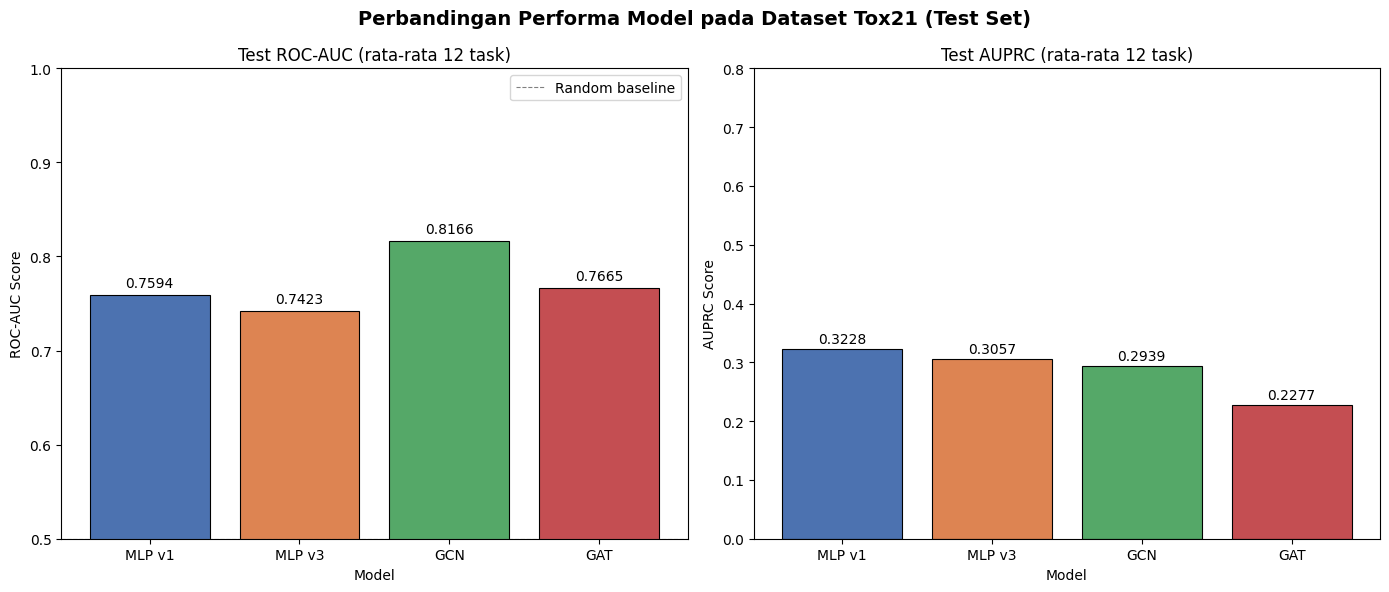

In [11]:
# Visualisasi 1 & 2: Bar chart perbandingan Test ROC-AUC dan Test AUPRC semua model
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Perbandingan Performa Model pada Dataset Tox21 (Test Set)', fontsize=14, fontweight='bold')

# Warna berbeda untuk setiap model agar mudah dibedakan
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
models_list = results_summary['Model'].tolist()

# Panel kiri: Test ROC-AUC
bars1 = axes[0].bar(models_list, results_summary['Test ROC'], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Test ROC-AUC (rata-rata 12 task)', fontsize=12)
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_xlabel('Model')
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
axes[0].legend()
# Menambahkan label nilai di atas setiap bar
for bar, val in zip(bars1, results_summary['Test ROC']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Panel kanan: Test AUPRC
bars2 = axes[1].bar(models_list, results_summary['Test PRC'], color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Test AUPRC (rata-rata 12 task)', fontsize=12)
axes[1].set_ylabel('AUPRC Score')
axes[1].set_xlabel('Model')
axes[1].set_ylim(0.0, 0.8)
for bar, val in zip(bars2, results_summary['Test PRC']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

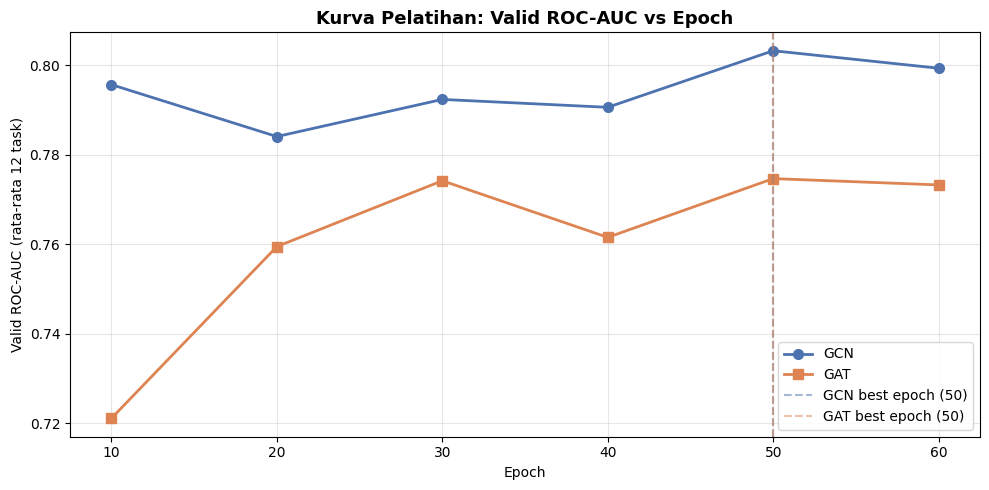

In [12]:
# Visualisasi 3: Kurva pelatihan - Valid ROC-AUC per epoch untuk GCN dan GAT
fig, ax = plt.subplots(figsize=(10, 5))

# Mengekstrak data riwayat pelatihan dari masing-masing model
gcn_epochs = [h['epoch'] for h in gcn_history]
gcn_rocs   = [h['valid_roc'] for h in gcn_history]
gat_epochs = [h['epoch'] for h in gat_history]
gat_rocs   = [h['valid_roc'] for h in gat_history]

ax.plot(gcn_epochs, gcn_rocs, 'o-', color='#4C72B0', linewidth=2, markersize=7, label='GCN')
ax.plot(gat_epochs, gat_rocs, 's-', color='#DD8452', linewidth=2, markersize=7, label='GAT')

# Menandai epoch terbaik dengan garis vertikal putus-putus
best_gcn_idx = gcn_rocs.index(max(gcn_rocs))
best_gat_idx = gat_rocs.index(max(gat_rocs))
ax.axvline(x=gcn_epochs[best_gcn_idx], color='#4C72B0', linestyle='--', alpha=0.5,
            label=f'GCN best epoch ({gcn_epochs[best_gcn_idx]})')
ax.axvline(x=gat_epochs[best_gat_idx], color='#DD8452', linestyle='--', alpha=0.5,
            label=f'GAT best epoch ({gat_epochs[best_gat_idx]})')

ax.set_title('Kurva Pelatihan: Valid ROC-AUC vs Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Valid ROC-AUC (rata-rata 12 task)')
ax.set_xticks(gcn_epochs)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Menghitung ROC-AUC per task menggunakan prediksi mentah dari model
# model.predict() mengembalikan array [n_samples, n_tasks, 2] (prob kelas 0 dan kelas 1)
print("Menghitung metrik per task...")

# Mengambil label dan bobot dari test dataset
y_true = test_dataset.y   # shape: [n_samples, n_tasks]
w_test = test_dataset.w   # bobot: 0 = data label hilang, >0 = label valid

# Mengambil prediksi probabilitas dari masing-masing model
gcn_preds = gcn_model.predict(test_dataset)  # [n_samples, n_tasks, 2]
gat_preds = gat_model.predict(test_dataset)

# Mengekstrak probabilitas kelas positif (toksik)
gcn_probs = gcn_preds[:, :, 1]  # [n_samples, n_tasks]
gat_probs = gat_preds[:, :, 1]

# Menghitung ROC-AUC per task, hanya untuk sampel dengan label valid (weight > 0)
per_task_roc = {'Task': tasks}
for model_name, probs in [('GCN', gcn_probs), ('GAT', gat_probs)]:
    task_rocs = []
    for t_idx in range(len(tasks)):
        mask = w_test[:, t_idx] > 0
        if mask.sum() > 0 and len(np.unique(y_true[mask, t_idx])) > 1:
            score = roc_auc_score(y_true[mask, t_idx], probs[mask, t_idx])
        else:
            score = np.nan  # Tidak cukup data untuk menghitung ROC-AUC
        task_rocs.append(score)
    per_task_roc[model_name] = task_rocs

# Menyusun tabel per task
per_task_df = pd.DataFrame(per_task_roc).set_index('Task')

print("\nROC-AUC per Task (Test Set):")
print("-" * 35)
print(per_task_df.round(4).to_string())

Menghitung metrik per task...

ROC-AUC per Task (Test Set):
-----------------------------------
                 GCN    GAT
Task                       
NR-AR         0.7876 0.7158
NR-AR-LBD     0.8244 0.7776
NR-AhR        0.8924 0.8483
NR-Aromatase  0.8230 0.8543
NR-ER         0.7431 0.7155
NR-ER-LBD     0.7721 0.7026
NR-PPAR-gamma 0.8943 0.7978
SR-ARE        0.8346 0.7820
SR-ATAD5      0.8377 0.7812
SR-HSE        0.8743 0.8149
SR-MMP        0.9189 0.8637
SR-p53        0.8567 0.7973


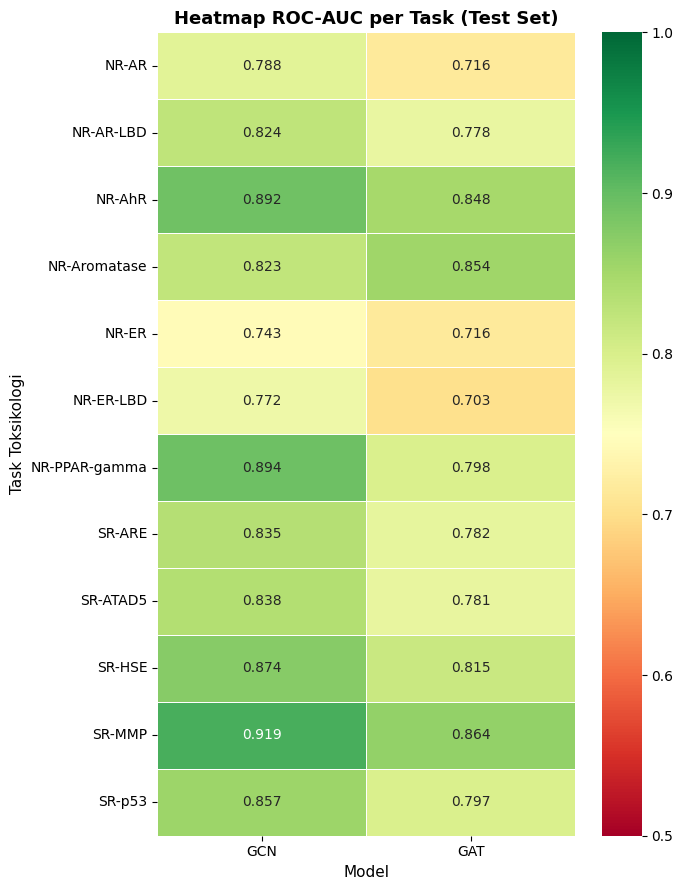

In [14]:
# Visualisasi 4: Heatmap ROC-AUC per task untuk setiap model
fig, ax = plt.subplots(figsize=(7, 9))

sns.heatmap(
    per_task_df,
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.5, vmax=1.0,
    linewidths=0.5, linecolor='white',
    ax=ax
)

ax.set_title('Heatmap ROC-AUC per Task (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Task Toksikologi', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [15]:
# Menentukan model GNN terbaik berdasarkan Test ROC-AUC tertinggi
gnn_rows = results_summary[results_summary['Model'].isin(['GCN', 'GAT'])]
best_model_name = gnn_rows.loc[gnn_rows['Test ROC'].idxmax(), 'Model']
best_probs      = gcn_probs if best_model_name == 'GCN' else gat_probs

print(f"Model GNN terbaik (Test ROC-AUC tertinggi): {best_model_name}")
print(f"Test ROC-AUC: {gnn_rows[gnn_rows['Model']==best_model_name]['Test ROC'].values[0]:.4f}")

Model GNN terbaik (Test ROC-AUC tertinggi): GCN
Test ROC-AUC: 0.8166


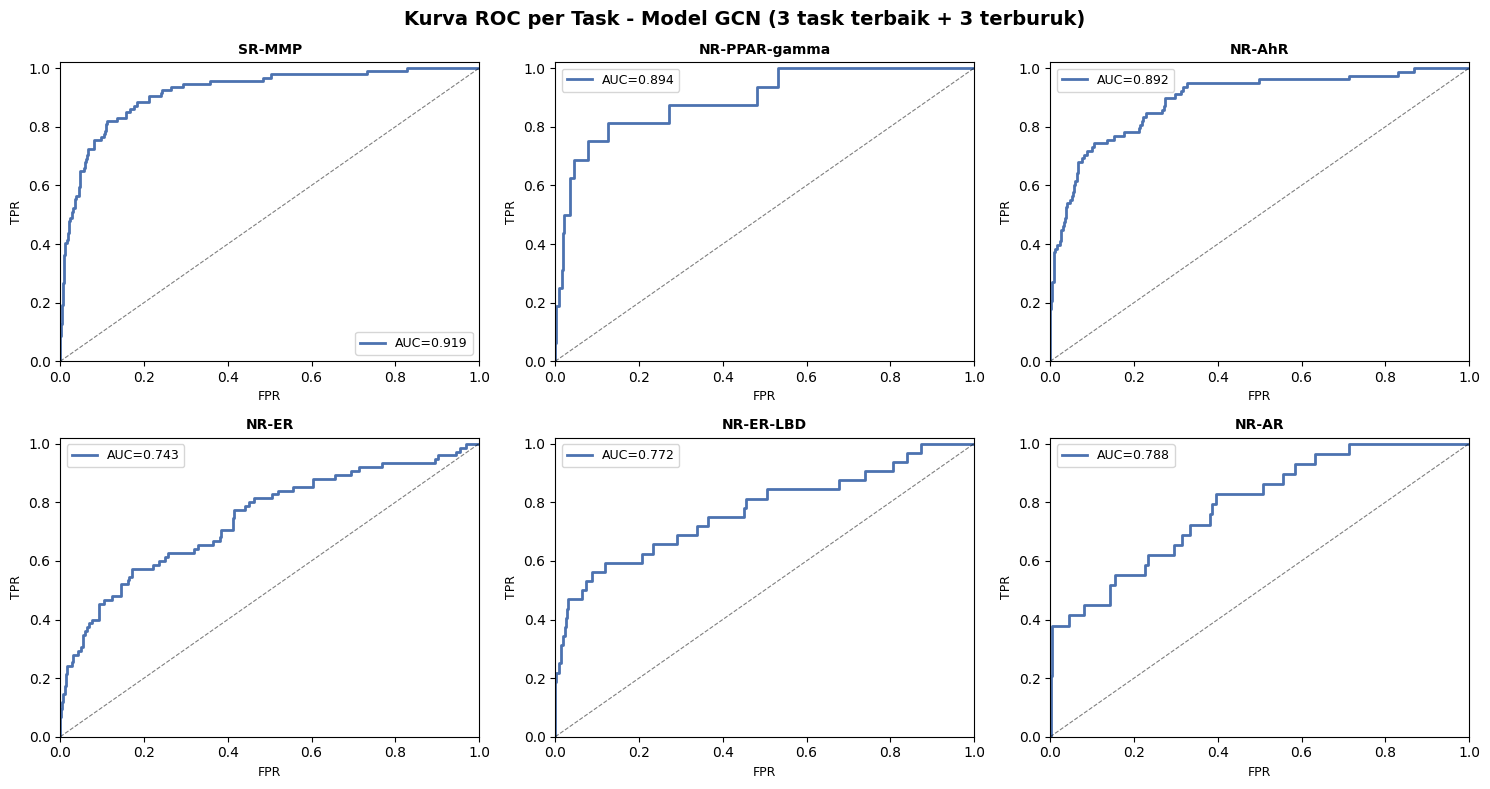

In [16]:
# Visualisasi 5: Kurva ROC per task - 3 task terbaik + 3 terburuk untuk model GNN terbaik
# Pilih task berdasarkan ROC-AUC pada test set untuk fokus ke diferensiasi paling informatif
scores = per_task_df[best_model_name].dropna()
top3 = scores.nlargest(3).index.tolist()
bot3 = scores.nsmallest(3).index.tolist()
tasks_to_plot = top3 + bot3

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Kurva ROC per Task - Model {best_model_name} (3 task terbaik + 3 terburuk)',
             fontsize=14, fontweight='bold')

for task, ax in zip(tasks_to_plot, axes.flatten()):
    t_idx = tasks.index(task)
    # Hanya menggunakan sampel dengan label valid (bobot > 0)
    mask = w_test[:, t_idx] > 0
    y_t  = y_true[mask, t_idx]
    p_t  = best_probs[mask, t_idx]

    if len(np.unique(y_t)) > 1:
        fpr, tpr, _ = roc_curve(y_t, p_t)
        roc_score   = auc(fpr, tpr)
        ax.plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'AUC={roc_score:.3f}')
    else:
        ax.text(0.5, 0.5, 'Hanya 1 kelas', ha='center', va='center', transform=ax.transAxes)

    # Garis diagonal sebagai referensi random classifier
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(task, fontsize=10, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=9)
    ax.set_ylabel('TPR', fontsize=9)
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()


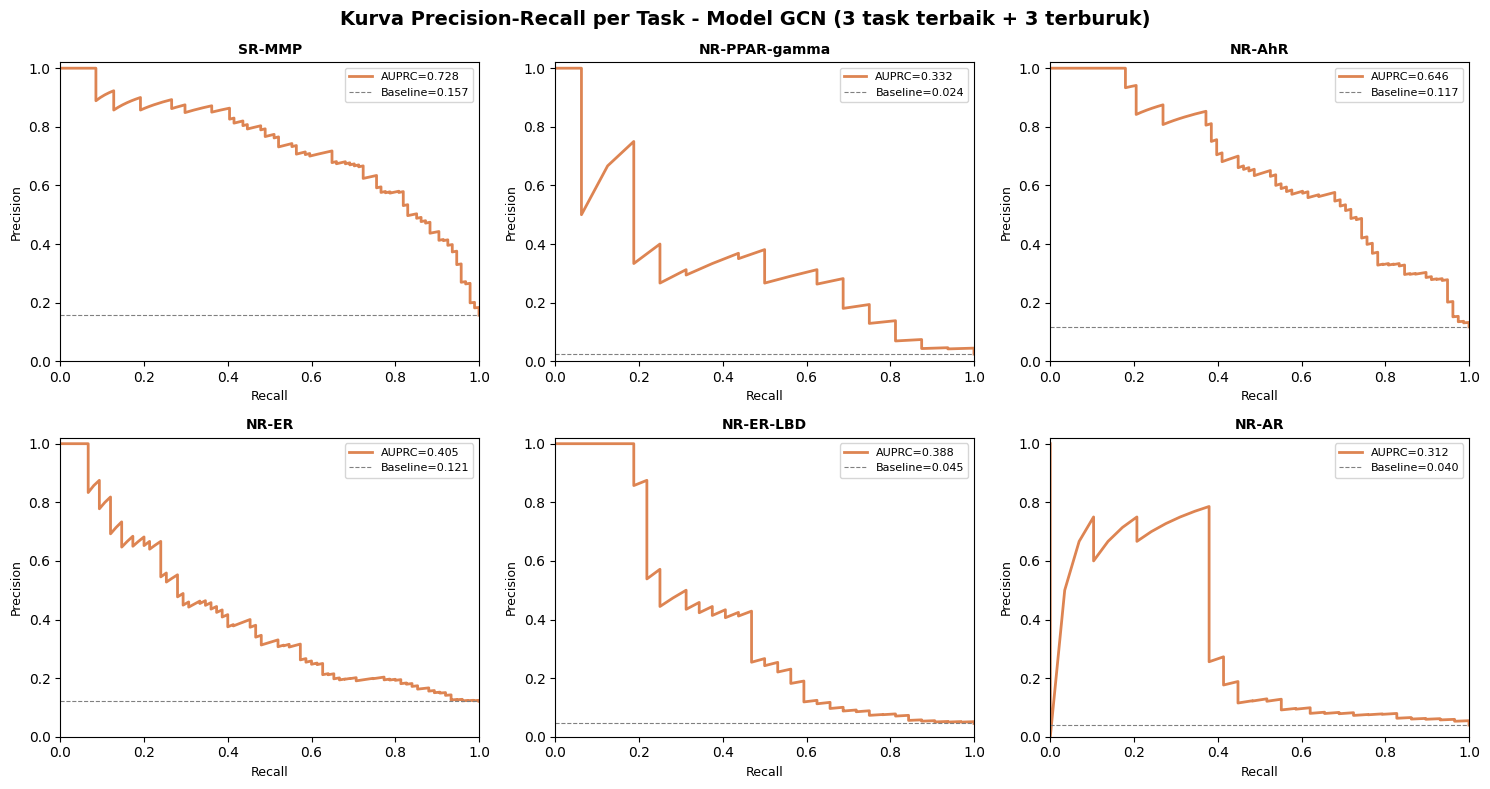

In [17]:
# Visualisasi 6: Kurva Precision-Recall per task - 3 task terbaik + 3 terburuk
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Kurva Precision-Recall per Task - Model {best_model_name} (3 task terbaik + 3 terburuk)',
             fontsize=14, fontweight='bold')

for task, ax in zip(tasks_to_plot, axes.flatten()):
    t_idx = tasks.index(task)
    mask = w_test[:, t_idx] > 0
    y_t  = y_true[mask, t_idx]
    p_t  = best_probs[mask, t_idx]

    # Prevalensi positif = baseline AUPRC untuk random classifier
    prevalence = y_t.mean() if len(y_t) > 0 else 0

    if len(np.unique(y_t)) > 1:
        prec, rec, _ = precision_recall_curve(y_t, p_t)
        prc_score    = auc(rec, prec)
        ax.plot(rec, prec, color='#DD8452', linewidth=2, label=f'AUPRC={prc_score:.3f}')
        ax.axhline(y=prevalence, color='gray', linestyle='--', linewidth=0.8,
                   label=f'Baseline={prevalence:.3f}')
    else:
        ax.text(0.5, 0.5, 'Hanya 1 kelas', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(task, fontsize=10, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=9)
    ax.set_ylabel('Precision', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()


## Analisis Per Task

In [18]:
# Mengidentifikasi task dengan performa terbaik dan terburuk untuk model terbaik
# Mengurutkan tabel dari ROC-AUC tertinggi ke terendah
pertask_sorted = per_task_df[[best_model_name]].copy()
pertask_sorted.columns = ['ROC-AUC']
pertask_sorted = pertask_sorted.sort_values('ROC-AUC', ascending=False)

print(f"Performa per Task - Model {best_model_name} (Test Set, diurutkan dari terbaik):")
print("-" * 40)
for task, row in pertask_sorted.iterrows():
    print(f"  {task:20s}: {row['ROC-AUC']:.4f}")

# Mengidentifikasi 3 task terbaik dan 3 terburuk
valid_scores = per_task_df[best_model_name].dropna()
best_tasks   = valid_scores.nlargest(3)
worst_tasks  = valid_scores.nsmallest(3)

print(f"\n3 Task TERBAIK ({best_model_name}):")
for task, score in best_tasks.items():
    print(f"  {task:20s}: {score:.4f}")

print(f"\n3 Task TERBURUK ({best_model_name}):")
for task, score in worst_tasks.items():
    print(f"  {task:20s}: {score:.4f}")

Performa per Task - Model GCN (Test Set, diurutkan dari terbaik):
----------------------------------------
  SR-MMP              : 0.9189
  NR-PPAR-gamma       : 0.8943
  NR-AhR              : 0.8924
  SR-HSE              : 0.8743
  SR-p53              : 0.8567
  SR-ATAD5            : 0.8377
  SR-ARE              : 0.8346
  NR-AR-LBD           : 0.8244
  NR-Aromatase        : 0.8230
  NR-AR               : 0.7876
  NR-ER-LBD           : 0.7721
  NR-ER               : 0.7431

3 Task TERBAIK (GCN):
  SR-MMP              : 0.9189
  NR-PPAR-gamma       : 0.8943
  NR-AhR              : 0.8924

3 Task TERBURUK (GCN):
  NR-ER               : 0.7431
  NR-ER-LBD           : 0.7721
  NR-AR               : 0.7876


## Export Model Artifacts untuk API Backend

Menyimpan daftar task dan metadata model agar FastAPI backend bisa load model dan menampilkan info ke frontend tanpa hardcode.

In [ ]:
# Menulis daftar 12 task dan metadata model ke folder checkpoints/
# File ini dibaca backend FastAPI saat startup untuk inisialisasi.
import json as _json

project_root = os.path.dirname(os.path.abspath(os.getcwd() + '/Tox21.ipynb'))
checkpoints_dir = os.path.join(project_root, 'checkpoints')
os.makedirs(checkpoints_dir, exist_ok=True)

# Daftar 12 task dengan deskripsi singkat untuk konteks frontend
task_descriptions = {
    'NR-AR':         'Androgen Receptor - disrupsi hormon reproduktif',
    'NR-AR-LBD':     'Androgen Receptor LBD - domain pengikatan ligand',
    'NR-AhR':        'Aryl hydrocarbon Receptor - aktivasi prokarsinogen',
    'NR-Aromatase':  'CYP19A1 - konversi androgen ke estrogen',
    'NR-ER':         'Estrogen Receptor - endocrine disruptor',
    'NR-ER-LBD':     'Estrogen Receptor LBD - domain pengikatan ligand',
    'NR-PPAR-gamma': 'PPAR-gamma - regulasi diferensiasi adiposit',
    'SR-ARE':        'Antioxidant Response Element - stres oksidatif',
    'SR-ATAD5':      'ATAD5 - kerusakan DNA',
    'SR-HSE':        'Heat Shock - misfolding protein',
    'SR-MMP':        'Mitochondrial Membrane Potential - prekursor apoptosis',
    'SR-p53':        'p53 - kerusakan DNA berat',
}

with open(os.path.join(checkpoints_dir, 'tasks.json'), 'w') as f:
    _json.dump({'tasks': list(tasks), 'descriptions': task_descriptions}, f, indent=2)

# Metadata model GCN (best model)
gcn_best_epoch = max(gcn_history, key=lambda h: h['valid_roc'])['epoch']
gat_best_epoch = max(gat_history, key=lambda h: h['valid_roc'])['epoch']

model_info = {
    'best_model': best_model_name,
    'gcn': {
        'checkpoint_dir': 'checkpoints/gcn_best',
        'best_epoch': gcn_best_epoch,
        'train_roc_auc': float(gcn_scores['train']['roc']),
        'valid_roc_auc': float(gcn_scores['valid']['roc']),
        'test_roc_auc':  float(gcn_scores['test']['roc']),
        'test_prc_auc':  float(gcn_scores['test']['prc']),
        'hyperparameters': {
            'graph_conv_layers': [128, 128],
            'dropout': 0.3,
            'learning_rate': 0.001,
            'batch_size': 64,
        },
    },
    'gat': {
        'checkpoint_dir': 'checkpoints/gat_best',
        'best_epoch': gat_best_epoch,
        'train_roc_auc': float(gat_scores['train']['roc']),
        'valid_roc_auc': float(gat_scores['valid']['roc']),
        'test_roc_auc':  float(gat_scores['test']['roc']),
        'test_prc_auc':  float(gat_scores['test']['prc']),
        'hyperparameters': {
            'n_attention_heads': 4,
            'dropout': 0.3,
            'learning_rate': 0.001,
        },
    },
    'featurizer': 'MolGraphConvFeaturizer(use_edges=True)',
    'n_tasks': len(tasks),
    'training': {
        'epochs_total': 60,
        'check_every': 10,
        'balancing_transformer': True,
        'split': 'random 80/10/10',
    },
}

with open(os.path.join(checkpoints_dir, 'model_info.json'), 'w') as f:
    _json.dump(model_info, f, indent=2)

print(f'[OK] Artifacts tersimpan di: {checkpoints_dir}')
print(f'      - tasks.json       ({len(tasks)} tasks)')
print(f'      - model_info.json  (best model: {best_model_name})')
print(f'      - {model_info["gcn"]["checkpoint_dir"]}/  (weights GCN)')
print(f'      - {model_info["gat"]["checkpoint_dir"]}/  (weights GAT)')

[OK] Artifacts tersimpan di: /home/qurne/Codingan/compBio/checkpoints
      - tasks.json       (12 tasks)
      - model_info.json  (best model: GCN)
      - checkpoints/gcn_best/  (weights GCN)
      - checkpoints/gat_best/  (weights GAT)


## Diskusi: GNN vs MLP untuk Data Molekuler

### Mengapa GNN Lebih Efektif dari MLP untuk Prediksi Toksisitas?

Mayr et al. (2016) dalam **DeepTox: Toxicity Prediction using Deep Learning** menunjukkan bahwa
arsitektur deep learning yang dapat menangkap representasi hierarkis dari data kimia secara
konsisten mengungguli metode berbasis fingerprint tradisional.

**Keterbatasan MLP dengan fingerprint (CircularFingerprint/ECFP):**
- Representasi ECFP adalah vektor biner tetap yang kehilangan informasi spasial tentang konektivitas atom
- Dua molekul berbeda dapat memiliki fingerprint identik (*hash collision*)
- MLP tidak bisa memanfaatkan struktur graf yang inheren dalam molekul
- Overfitting parah terlihat dari gap Train ROC (0.99) vs Test ROC (0.75) pada baseline MLP

**Keunggulan GNN (GCN/GAT):**
- Bekerja langsung pada representasi graf molekul — atom sebagai *node*, ikatan sebagai *edge*
- GCN mengagregasi informasi dari atom tetangga secara iteratif, menangkap konteks kimia lokal
- GAT menggunakan *attention mechanism* untuk memberi bobot berbeda pada tetangga yang lebih
  relevan secara kimiawi (gugus fungsi reaktif mendapat bobot lebih tinggi)
- Pembelajaran representasi bersifat *end-to-end* tanpa rekayasa fitur manual
- Train-test gap yang lebih kecil = generalisasi lebih baik

### Ketidakseimbangan Kelas dan Pentingnya AUPRC

Cavasotto & Scardino (2022) dalam **In Silico Drug Discovery and Design** menekankan bahwa
dataset toksikologi seperti Tox21 memiliki karakteristik **ketidakseimbangan kelas yang parah**:
proporsi molekul toksik (positif) jauh lebih sedikit dari non-toksik (sekitar 3–15%).

**Mengapa ROC-AUC bisa menyesatkan pada data imbalanced:**
- ROC-AUC dihitung dari TPR (True Positive Rate) vs FPR (False Positive Rate)
- Dengan kelas negatif yang sangat banyak, FPR tetap rendah meskipun banyak prediksi False Positive
- Model yang bias ke kelas negatif dapat memperoleh ROC-AUC tinggi secara artifisial

**Mengapa AUPRC lebih informatif:**
- Precision-Recall curve tidak melibatkan True Negative sama sekali
- AUPRC sensitif terhadap kemampuan model mendeteksi kelas positif yang langka
- Baseline AUPRC untuk random classifier = *prevalensi* kelas positif (misal 10%), bukan 0.5
- AUPRC yang rendah mengindikasikan model kesulitan mendeteksi molekul toksik secara tepat

**Strategi yang diterapkan dalam notebook ini:**
- `BalancingTransformer` menyesuaikan bobot sampel untuk mengurangi bias ke kelas negatif
- Pelaporan AUPRC sejajar ROC-AUC memberikan gambaran performa yang lebih lengkap dan jujur

### Keterbatasan dan Peningkatan yang Mungkin Dilakukan

**Keterbatasan saat ini:**
1. **GTX 1650 VRAM terbatas (4 GB)** — batch size kecil (64) dan model dengan hidden dim besar
   akan terkena OOM. Speedup GPU tidak signifikan untuk dataset kecil (6K molekul, molekul kecil)
   karena overhead transfer CPU↔GPU melebihi manfaat paralelisme GPU
2. **Hanya 60 epoch** — beberapa GNN memerlukan >200 epoch untuk konvergensi penuh;
   dengan GPU tersedia, menambah epoch tidak menambah waktu secara signifikan
3. **Hyperparameter default** — belum dioptimasi melalui grid search atau Bayesian optimization
4. **DGL 2.4.0 (bukan 2.5.0)** — versi terbaru di CDN DGL untuk folder torch-2.5 masih HTTP 403;
   versi 2.4.0 sudah stabil dan kompatibel dengan DeepChem 2.8

**Peningkatan yang direkomendasikan:**
1. **Tambah epoch** — coba 150–200 epoch, early stopping akan mencegah overfitting
2. **Naikkan batch_size** — coba 128 atau 256 untuk utilisasi GPU lebih optimal
3. **AttentiveFPModel** (Xiong et al. 2020) — model GNN state-of-the-art untuk prediksi
   properti molekuler; kini bisa dijalankan dengan DGL CUDA yang sudah terpasang
4. **Ensemble model** — rata-rata prediksi GCN + GAT biasanya meningkatkan ~1-2% ROC-AUC
5. **Optuna hyperparameter tuning** — cari learning rate, hidden dim, n_layers optimal
6. **Transfer learning** — pre-training pada dataset lebih besar (ChEMBL) lalu fine-tuning pada Tox21
7. **Per-task threshold tuning** — optimalkan threshold klasifikasi per task sesuai konteks klinis

In [20]:
# Memprediksi toksisitas untuk 5 contoh molekul menggunakan model terbaik
# Demonstrasi penggunaan model untuk prediksi senyawa baru
print(f"Prediksi toksisitas menggunakan model: {best_model_name}")
print("=" * 60)

# Daftar SMILES contoh dan nama senyawanya
example_smiles = {
    'Aspirin':     'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine':    'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
    'Paracetamol': 'CC(=O)Nc1ccc(O)cc1',
    'Benzene':     'c1ccccc1',
    'Ethanol':     'CCO',
}

# Menggunakan featurizer yang sama dengan training
featurizer  = dc.feat.MolGraphConvFeaturizer(use_edges=True)
smiles_list = list(example_smiles.values())
features    = featurizer.featurize(smiles_list)

# Membuat dataset dummy untuk prediksi (label tidak diperlukan)
pred_dataset = dc.data.NumpyDataset(
    X=features,
    y=np.zeros((len(smiles_list), len(tasks))),
    ids=smiles_list
)

# Memilih model terbaik untuk prediksi
best_model = gcn_model if best_model_name == 'GCN' else gat_model

# Melakukan prediksi - output adalah probabilitas kelas toksik
predictions  = best_model.predict(pred_dataset)  # [n_mol, n_tasks, 2]
proba_toxic  = predictions[:, :, 1]              # probabilitas kelas 1 (toksik)

# Menyusun hasil prediksi dalam DataFrame yang mudah dibaca
pred_df = pd.DataFrame(
    proba_toxic,
    index=list(example_smiles.keys()),
    columns=tasks
)

print("\nProbabilitas Toksisitas per Endpoint (0 = aman, 1 = toksik):")
print("-" * 60)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(pred_df.T.to_string())

print("\n" + "="*60)
print("Ringkasan: endpoint dengan probabilitas toksisitas tertinggi per molekul")
print("="*60)
for mol_name, row in pred_df.iterrows():
    most_toxic_task  = row.idxmax()
    most_toxic_score = row.max()
    flag = '(!) PERLU PERHATIAN' if most_toxic_score > 0.5 else ''
    print(f"  {mol_name:12s}: {most_toxic_task:15s} = {most_toxic_score:.3f} {flag}")

Prediksi toksisitas menggunakan model: GCN

Probabilitas Toksisitas per Endpoint (0 = aman, 1 = toksik):
------------------------------------------------------------
               Aspirin  Caffeine  Paracetamol  Benzene  Ethanol
NR-AR            0.254     0.043        0.597    0.369    0.194
NR-AR-LBD        0.013     0.009        0.250    0.044    0.098
NR-AhR           0.124     0.091        0.656    0.178    0.069
NR-Aromatase     0.091     0.028        0.296    0.035    0.074
NR-ER            0.326     0.096        0.606    0.304    0.099
NR-ER-LBD        0.116     0.095        0.181    0.074    0.020
NR-PPAR-gamma    0.203     0.002        0.136    0.068    0.053
SR-ARE           0.130     0.265        0.488    0.081    0.140
SR-ATAD5         0.092     0.035        0.543    0.027    0.014
SR-HSE           0.089     0.063        0.207    0.122    0.087
SR-MMP           0.024     0.012        0.434    0.062    0.017
SR-p53           0.053     0.116        0.495    0.030    0.026

R